In [81]:
import os
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from torch.utils.data import WeightedRandomSampler

In [17]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [18]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Magic
[nltk_data]     Systems\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Magic
[nltk_data]     Systems\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Magic
[nltk_data]     Systems\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Magic
[nltk_data]     Systems\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [20]:
data_path = "Dataset---Hate-Speech-Detection-using-Deep-Learning.csv"

In [21]:
df = pd.read_csv(data_path)
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [22]:
df.shape

(24783, 2)

In [23]:
df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

## Note on Class Labels
Based on the standard convention for this publicly available hate speech dataset
(Davidson et al.), the labels are commonly interpreted as:
- 0 = Hate Speech
- 1 = Offensive Language
- 2 = Neither

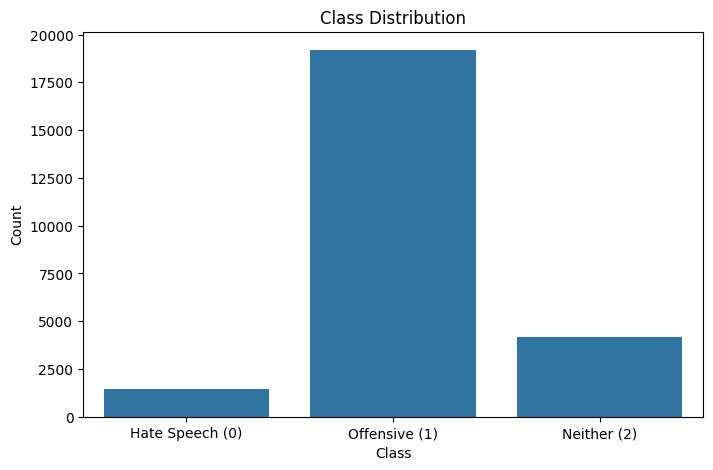

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks([0, 1, 2], ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)'])
plt.show()

In [25]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [28]:
df['cleaned_tweet'] = df['tweet'].apply(preprocess_text)

In [31]:
tweet_lengths = df['cleaned_tweet'].apply(lambda x: len(x.split()))

print(f"Max length: {tweet_lengths.max()}")
print(f"Min length: {tweet_lengths.min()}")
print(f"Average length: {tweet_lengths.mean():.2f}")

Max length: 30
Min length: 1
Average length: 8.78


In [38]:
for cap in [5000, 10000, 15000, 20000, 25000, len(word_counts)]:
    words_at_cap = word_counts.most_common(cap)
    covered = sum(count for word, count in words_at_cap)
    pct = (covered / total_occurrences) * 100
    print(f"Cap: {cap:6d} | Coverage: {pct:.2f}%")

Cap:   5000 | Coverage: 83.73%
Cap:  10000 | Coverage: 89.56%
Cap:  15000 | Coverage: 92.43%
Cap:  20000 | Coverage: 94.73%
Cap:  25000 | Coverage: 97.03%
Cap:  31464 | Coverage: 100.00%


In [39]:
all_words = ' '.join(df['cleaned_tweet']).split()
word_counts = Counter(all_words)

print(f"Total unique words: {len(word_counts)}")

max_vocab_size = 20000
most_common_words = word_counts.most_common(max_vocab_size)

vocab = {word: idx + 2 for idx, (word, count) in enumerate(most_common_words)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

vocab_size = len(vocab)
print(f"Vocabulary size (capped): {vocab_size}")

Total unique words: 31464
Vocabulary size (capped): 20002


In [40]:
def text_to_sequence(text, vocab):
    return [vocab.get(word, vocab['<UNK>']) for word in text.split()]

df['sequence'] = df['cleaned_tweet'].apply(lambda x: text_to_sequence(x, vocab))

In [35]:
max_length = 30  # we'll adjust this once you share the Step 1 stats

def pad_sequence(seq, max_length):
    if len(seq) >= max_length:
        return seq[:max_length]
    else:
        return seq + [vocab['<PAD>']] * (max_length - len(seq))

df['padded_sequence'] = df['sequence'].apply(lambda x: pad_sequence(x, max_length))

In [52]:
X = np.array(df['padded_sequence'].tolist())
y = df['class'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 17347
Validation samples: 3718
Testing samples: 3718


In [53]:
class TweetDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [100]:
train_dataset = TweetDataset(X_train, y_train)
val_dataset = TweetDataset(X_val, y_val)
test_dataset = TweetDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [101]:
class_counts = Counter(y_train)
total_samples = len(y_train)
num_classes = len(class_counts)

class_weights = [total_samples / class_counts[i] for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([17.3297,  1.2915,  5.9530])


In [102]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

In [103]:
vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 256
output_dim = 3
num_layers =2
dropout = 0.3

rnn_model = SimpleRNN(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers = num_layers, dropout = dropout)

In [104]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_model = rnn_model.to(device)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = optim.Adam(rnn_model.parameters(), lr=0.0005)

epochs = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

In [105]:
for epoch in range(epochs):
    rnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = rnn_model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), max_norm=5)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    rnn_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for sequences, labels in val_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = rnn_model(sequences)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(rnn_model.state_dict(), "best_rnn_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/20 | Train Loss: 1.1317 | Train Acc: 41.60% | Val Loss: 1.1461 | Val Acc: 18.61%
Epoch 2/20 | Train Loss: 1.1204 | Train Acc: 35.47% | Val Loss: 1.1075 | Val Acc: 50.51%
Epoch 3/20 | Train Loss: 1.1068 | Train Acc: 36.76% | Val Loss: 1.1129 | Val Acc: 40.51%
Epoch 4/20 | Train Loss: 1.1082 | Train Acc: 40.02% | Val Loss: 1.1064 | Val Acc: 34.02%
Epoch 5/20 | Train Loss: 1.1032 | Train Acc: 43.28% | Val Loss: 1.0958 | Val Acc: 42.36%
Epoch 6/20 | Train Loss: 1.1027 | Train Acc: 40.76% | Val Loss: 1.0908 | Val Acc: 53.95%
Epoch 7/20 | Train Loss: 1.1021 | Train Acc: 41.93% | Val Loss: 1.1028 | Val Acc: 48.36%
Epoch 8/20 | Train Loss: 1.1047 | Train Acc: 41.62% | Val Loss: 1.1020 | Val Acc: 33.78%
Epoch 9/20 | Train Loss: 1.1042 | Train Acc: 41.52% | Val Loss: 1.0963 | Val Acc: 40.72%
Early stopping triggered at epoch 9


In [106]:
from collections import Counter

rnn_model.eval()
all_preds = []
with torch.no_grad():
    for sequences, labels in val_loader:
        sequences = sequences.to(device)
        outputs = rnn_model(sequences)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())

print(Counter(all_preds))

Counter({np.int64(2): 2173, np.int64(1): 1340, np.int64(0): 205})


In [107]:
rnn_model.eval()
val_preds = []
val_true = []
with torch.no_grad():
    for sequences, labels in val_loader:
        sequences = sequences.to(device)
        outputs = rnn_model(sequences)
        _, predicted = outputs.max(1)
        val_preds.extend(predicted.cpu().numpy())
        val_true.extend(labels.numpy())

print(classification_report(val_true, val_preds, target_names=['Hate Speech', 'Offensive', 'Neither']))

              precision    recall  f1-score   support

 Hate Speech       0.05      0.05      0.05       215
   Offensive       0.81      0.38      0.52      2879
     Neither       0.19      0.66      0.30       624

    accuracy                           0.41      3718
   macro avg       0.35      0.36      0.29      3718
weighted avg       0.66      0.41      0.45      3718



In [108]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

In [109]:
lstm_model = LSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=num_layers, dropout=dropout)
lstm_model = lstm_model.to(device)

In [110]:
lstm_criterion = nn.CrossEntropyLoss(weight=class_weights)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.0005, weight_decay=1e-5)

lstm_epochs = 20
lstm_train_losses = []
lstm_val_losses = []
lstm_train_accuracies = []
lstm_val_accuracies = []

lstm_best_val_loss = float("inf")
lstm_patience = 3
lstm_patience_counter = 0

In [111]:
for epoch in range(lstm_epochs):
    lstm_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        lstm_optimizer.zero_grad()
        outputs = lstm_model(sequences)
        loss = lstm_criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5)
        lstm_optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    lstm_train_losses.append(epoch_train_loss)
    lstm_train_accuracies.append(epoch_train_acc)

    lstm_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for sequences, labels in val_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = lstm_model(sequences)
            loss = lstm_criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    lstm_val_losses.append(epoch_val_loss)
    lstm_val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{lstm_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if epoch_val_loss < lstm_best_val_loss:
        lstm_best_val_loss = epoch_val_loss
        lstm_patience_counter = 0
        torch.save(lstm_model.state_dict(), "best_lstm_model.pth")
    else:
        lstm_patience_counter += 1

    if lstm_patience_counter >= lstm_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/20 | Train Loss: 1.0179 | Train Acc: 65.75% | Val Loss: 0.8312 | Val Acc: 81.41%
Epoch 2/20 | Train Loss: 0.8280 | Train Acc: 82.09% | Val Loss: 0.7852 | Val Acc: 84.08%
Epoch 3/20 | Train Loss: 0.6919 | Train Acc: 82.54% | Val Loss: 0.6715 | Val Acc: 82.65%
Epoch 4/20 | Train Loss: 0.5850 | Train Acc: 81.42% | Val Loss: 0.6420 | Val Acc: 83.73%
Epoch 5/20 | Train Loss: 0.5527 | Train Acc: 81.60% | Val Loss: 0.6117 | Val Acc: 82.71%
Epoch 6/20 | Train Loss: 0.5137 | Train Acc: 82.21% | Val Loss: 0.6224 | Val Acc: 84.29%
Epoch 7/20 | Train Loss: 0.4793 | Train Acc: 82.49% | Val Loss: 0.5619 | Val Acc: 81.31%
Epoch 8/20 | Train Loss: 0.4441 | Train Acc: 82.84% | Val Loss: 0.5940 | Val Acc: 83.30%
Epoch 9/20 | Train Loss: 0.4139 | Train Acc: 83.35% | Val Loss: 0.6118 | Val Acc: 78.73%
Epoch 10/20 | Train Loss: 0.3835 | Train Acc: 84.31% | Val Loss: 0.5715 | Val Acc: 82.41%
Early stopping triggered at epoch 10


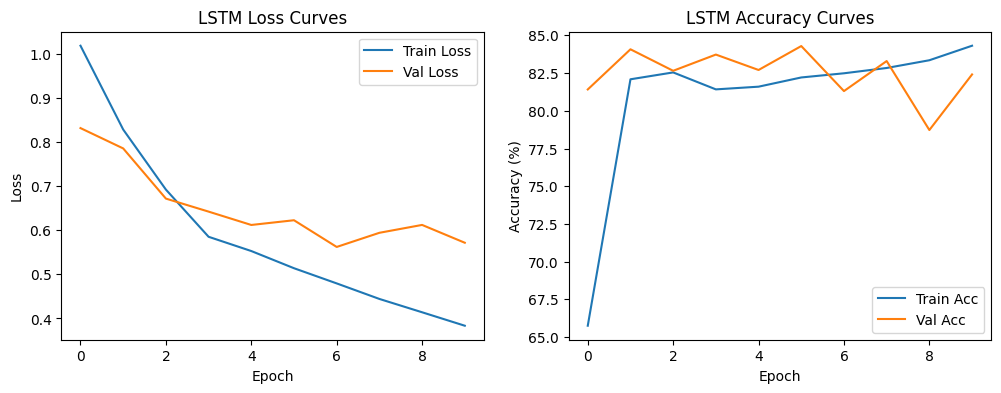

In [112]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label="Train Loss")
plt.plot(lstm_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(lstm_train_accuracies, label="Train Acc")
plt.plot(lstm_val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("LSTM Accuracy Curves")

plt.show()

              precision    recall  f1-score   support

 Hate Speech       0.22      0.67      0.34       214
   Offensive       0.98      0.79      0.88      2879
     Neither       0.75      0.89      0.81       625

    accuracy                           0.80      3718
   macro avg       0.65      0.78      0.68      3718
weighted avg       0.90      0.80      0.83      3718



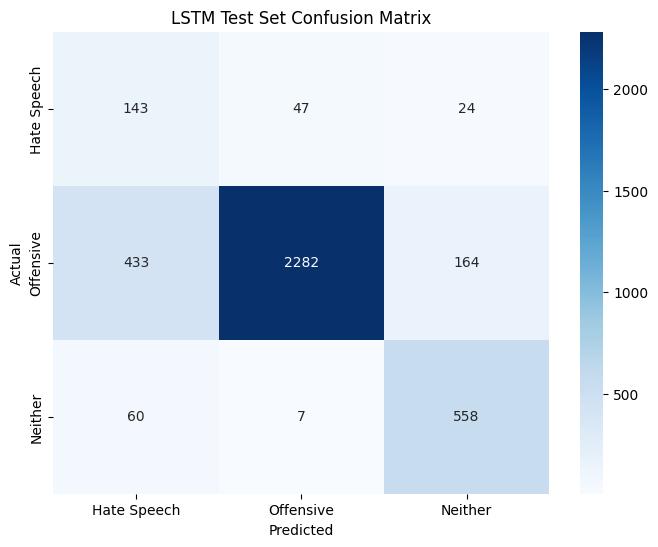

In [113]:
lstm_model.load_state_dict(torch.load("best_lstm_model.pth"))
lstm_model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        outputs = lstm_model(sequences)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_true.extend(labels.numpy())

print(classification_report(test_true, test_preds, target_names=['Hate Speech', 'Offensive', 'Neither']))

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['Hate Speech', 'Offensive', 'Neither'], yticklabels=['Hate Speech', 'Offensive', 'Neither'], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Test Set Confusion Matrix")
plt.show()

In [114]:
torch.save(lstm_model.state_dict(), "best_lstm_model.pth")

import pickle
with open("tokenizer_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)